# EPInformer — load Hugging Face checkpoints and reproduce performance

This notebook runs real inference with the pretrained checkpoints from
[`JiecongLin/EPInformer`](https://huggingface.co/JiecongLin/EPInformer):

- **Part 1 — Enhancer encoder**: the original KLF1 demo plus pooled 12-fold K562 evaluation using
  `enhancer_encoders/K562/fold_{1..12}.pt`.
- **Part 2 — Gene expression**: pooled 12-fold K562 RNA and CAGE evaluation using the shipped
  `expression_models/K562/{RNA,CAGE}/f3/` checkpoints.

The Hub revision is pinned below. Checkpoints download automatically only when the configured local
directory is missing; no token is required because the repository is public. For HPC use, point
`EPINFORMER_HF_CHECKPOINT_ROOT` at a persistent Lustre copy. Run from the pipeline repository root.

In [1]:
%matplotlib inline
import gc, os, sys, glob
from pathlib import Path
import numpy as np, pandas as pd
import torch
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style('white')
import kipoiseq
sys.path.insert(0, '.')
from EPInformer.models import EPInformer_v2, enhancer_predictor_256bp
from preprocessing.fasta import FastaStringExtractor

device = 'cuda' if torch.cuda.is_available() else 'cpu'
CELL = 'K562'
FASTA = 'data/reference/hg38/hg38.fa'
EXPR_CSV = 'data/GM12878_K562_18377_gene_expr_fromXpresso_with_sequence_strand.csv'
SPLIT_CSV = 'data/leave_chrom_out_crossvalidation_split_18377genes.csv'
ENCODER_DATA_CSV = os.environ.get(
    'EPINFORMER_ENCODER_DATA_CSV',
    f'batch_output/{CELL}/links/{CELL}_peak_5bins_around_summit_activity_sequence.csv')

HF_REPO_ID = 'JiecongLin/EPInformer'
HF_REVISION = '667a74e6a1358bee35fd1951570839bdeb5dec24'
HF_CHECKPOINT_ROOT = Path(os.environ.get(
    'EPINFORMER_HF_CHECKPOINT_ROOT', 'checkpoints/EPInformer-hf'))

def ensure_hf_checkpoints(root=HF_CHECKPOINT_ROOT):
    marker = root / 'enhancer_encoders' / 'K562' / 'fold_1.pt'
    if not marker.is_file():
        print(f'Checkpoint tree missing at {root}; downloading pinned Hub snapshot...')
        from huggingface_hub import snapshot_download
        snapshot_download(
            repo_id=HF_REPO_ID, revision=HF_REVISION, local_dir=str(root),
            token=os.environ.get('HF_TOKEN') or None)
    encoder_files = list((root / 'enhancer_encoders').glob('*/fold_*.pt'))
    expression_files = list((root / 'expression_models').glob('*/*/f*/fold_*.pt'))
    if len(encoder_files) != 72 or len(expression_files) != 288:
        raise RuntimeError(
            f'Incomplete checkpoint snapshot: {len(encoder_files)}/72 encoder and '
            f'{len(expression_files)}/288 expression checkpoints')
    return root

HF_CHECKPOINT_ROOT = ensure_hf_checkpoints()
print('device:', device)
print('checkpoint root:', HF_CHECKPOINT_ROOT.resolve())
print('Hub revision:', HF_REVISION)

def one_hot(seq):
    return kipoiseq.transforms.functional.one_hot_dna(seq, neutral_value=0.0).astype(np.float32)

device: cuda
checkpoint root: /lustre/grp/zyjlab/linjc/EPInformer_github_pipeline_test_20260715/checkpoints/EPInformer-hf
Hub revision: 667a74e6a1358bee35fd1951570839bdeb5dec24


## Part 1 — Enhancer activity + ISM at the KLF1 enhancer (faithful reproduction of pinellolab's `predict_enhancer_activity.ipynb`)

Predict K562 enhancer activity in 256-bp windows across the CRISPRi-validated **KLF1** enhancer, then
run in-silico saturation mutagenesis (ISM) to expose the TF motif — reproducing the upstream
EPInformer notebook **cell-for-cell** with the **published fold-8 encoder**, the **hg19** genome, and the
Fulco-2019 CRISPRi-FlowFISH table (`iloc[1]` → hg19 `chr19:12,978,355`, ≈ −20 kb from the KLF1 TSS).
The upstream `predict_enhancer_activity` returns **raw** activity (`2**pred - 0.1`) over 12 windows.
Only two lines differ from upstream: the `tangermeme.ism`→`tangermeme.saturation_mutagenesis` rename
and the local hg19 FASTA path. (A hg38 / log2 / multi-build view of the same encoder is in
`reproduce_github_enhancer_activity.ipynb`'s sibling notebook history.)

In [2]:
# Published pinellolab K562 encoder (fold 8) -- the exact checkpoint from predict_enhancer_activity.ipynb.
# This Part-1 section runs on CPU to match upstream exactly (encoder output is device-independent).
enc = enhancer_predictor_256bp()   # CPU
enc_ckpt = 'trained_models/pretrained_enhancer_encoder/fold_8_best_K562_seq2activityLog2_leaveChrOut_combinedRS_2bins_bs64_H3K27ac_adamW_erisxdl_r0_checkpoint.pt'
enc.load_state_dict(torch.load(enc_ckpt, map_location='cpu', weights_only=False)['model_state_dict'])
enc.eval()

# ISM: tangermeme.ism was renamed tangermeme.saturation_mutagenesis in >=1.x (identical function)
try:
    from tangermeme.ism import saturation_mutagenesis
except ModuleNotFoundError:
    from tangermeme.saturation_mutagenesis import saturation_mutagenesis
from tangermeme.plot import plot_logo

# upstream scripts/utils.py helpers, verbatim; only the hg19 path points at our local symlink
HG19_FASTA = 'data/reference/hg19/hg19.fa'

def one_hot_encode(sequence):
    return kipoiseq.transforms.functional.one_hot_dna(sequence).astype(np.float32)

def predict_enhancer_activity(enhancer_model, chrom, position, window_size=1024, stride=128,
                              device='cpu', fasta_path=HG19_FASTA):
    hg19_fasta_extractor = FastaStringExtractor(fasta_path)
    center = position
    print('The extened enhancer region: {}:{}-{}'.format(chrom, center - window_size, center + window_size))
    info_list = []
    for i in range(center - window_size, center + window_size, stride):
        seq = hg19_fasta_extractor.extract(kipoiseq.Interval(chrom, i, i + 256))
        seq_code = one_hot_encode(seq)[np.newaxis, np.newaxis, :]
        with torch.no_grad():
            pred = enhancer_model(torch.Tensor(seq_code).to(device)).cpu().detach().numpy()[0]
            pred_ori = 2 ** pred - 0.1
        info_list.append([chrom, i, i + 256, seq, center, pred_ori])
    return pd.DataFrame(info_list, columns=['chrom', 'start', 'end', 'seq', 'enhancer_mid', 'pred'])

In [3]:
# Fulco-2019 CRISPRi-FlowFISH (Nat Genet 41588_2019_538, Suppl Table 6a): CRISPRi-validated KLF1 enhancers
flowfish_df = pd.read_excel('data/CRISPRi-FlowFISH_Fulco2019/41588_2019_538_MOESM3_ESM.xlsx',
                            sheet_name='Supplementary Table 6a', skiprows=[0])
flowfish_df['mid'] = flowfish_df['start'] + (flowfish_df['end'] - flowfish_df['start']) / 2
flowfish_df['Distance_withDirect'] = flowfish_df['mid'] - flowfish_df['Gene TSS']
flowfish_df['Distance'] = np.abs(flowfish_df['Distance_withDirect'])
flowfish_100kb_df = flowfish_df[flowfish_df['Distance'] < 100_000]
KLF1_validated_enhancers = flowfish_100kb_df[(flowfish_100kb_df['Gene'] == 'KLF1') &
                                             (flowfish_100kb_df['Significant']) &
                                             (flowfish_100kb_df['Fraction change in gene expr'] < 0)].reset_index()

enhancer_locus = KLF1_validated_enhancers.iloc[1]['mid']
enhancer_chrom = KLF1_validated_enhancers.iloc[1]['chr']
pred_info = predict_enhancer_activity(enc, enhancer_chrom, int(enhancer_locus), window_size=512 + 256, stride=128, device='cpu')
KLF1_validated_enhancers[['chr', 'start', 'end', 'mid', 'Gene TSS', 'Distance_withDirect', 'Fraction change in gene expr']]

The extened enhancer region: chr19:12977587-12979123


,chr,start,end,mid,Gene TSS,Distance_withDirect,Fraction change in gene expr
0,chr19,12958325,12958825,12958575.0,12998017,-39442.0,-0.057784
1,chr19,12977965,12978745,12978355.0,12998017,-19662.0,-0.026087
2,chr19,12992085,12992645,12992365.0,12998017,-5652.0,-0.161863
3,chr19,12999705,13000205,12999955.0,12998017,1938.0,-0.169294
4,chr19,13001505,13002192,13001848.5,12998017,3831.5,-0.124012


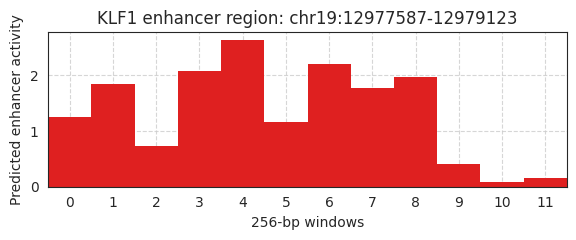

In [4]:
plt.figure(figsize=(6, 2.5))
sns.barplot(x=pred_info.index, y='pred', data=pred_info, color='red', width=1, linewidth=0)
plt.grid(linestyle='--', alpha=0.8)
plt.ylabel('Predicted enhancer activity')
plt.xlabel('256-bp windows')
plt.title('KLF1 enhancer region: chr19:12977587-12979123')
plt.tight_layout(); plt.show()

### In-silico saturation mutagenesis (motif discovery)
Mutate every base of the top-activity 256-bp window and plot the effect with `plot_logo` — TF motifs
appear as tall letters (GATA + ETS/GGAA at this KLF1 enhancer).

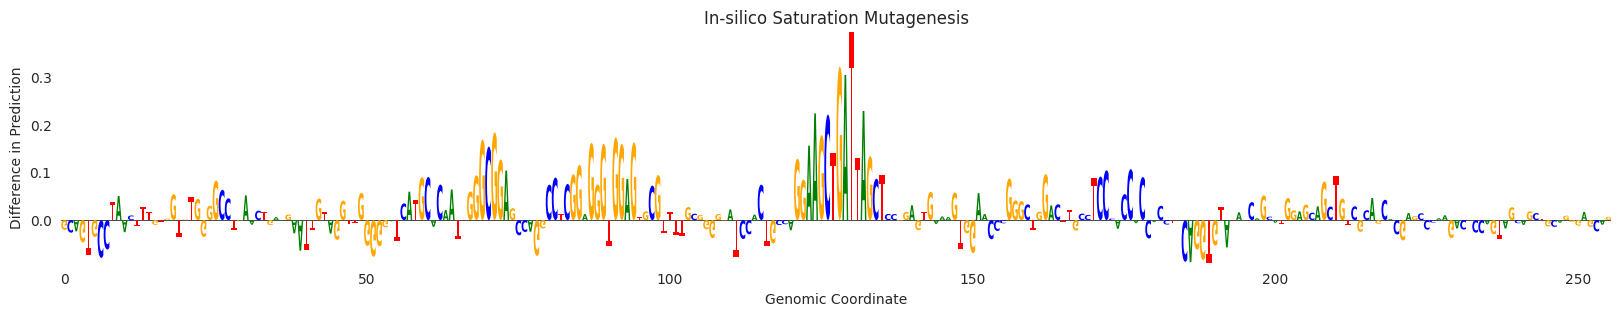

In [5]:
# calculate ISM score for the top 256-bp window
top_activity_256bp = pred_info.sort_values(by='pred', ascending=False).iloc[0]
seq_ohe = one_hot_encode(top_activity_256bp.seq)
seq_tensor = torch.from_numpy(seq_ohe).unsqueeze(0).permute(0, 2, 1)
seq_ISM = saturation_mutagenesis(enc, seq_tensor, device='cpu')

plt.figure(figsize=(20, 3))
ax = plt.subplot(111)
plot_logo(seq_ISM[0], ax=ax)
plt.xlabel("Genomic Coordinate")
plt.ylabel("Difference in Prediction")
plt.title("In-silico Saturation Mutagenesis")
plt.show()

### Hugging Face 12-fold enhancer evaluation (K562)

This is fresh inference, not a read of previously saved prediction CSVs. Each held-out chromosome
fold loads `enhancer_encoders/K562/fold_i.pt`. Predictions are averaged across forward and
reverse-complement sequence orientations, matching the checkpoint card's pooled K562 target
(Pearson R ≈ 0.740).

Hugging Face K562 encoder: pooled Pearson R=0.7427, expected≈0.740, delta=+0.0027, n=286,780


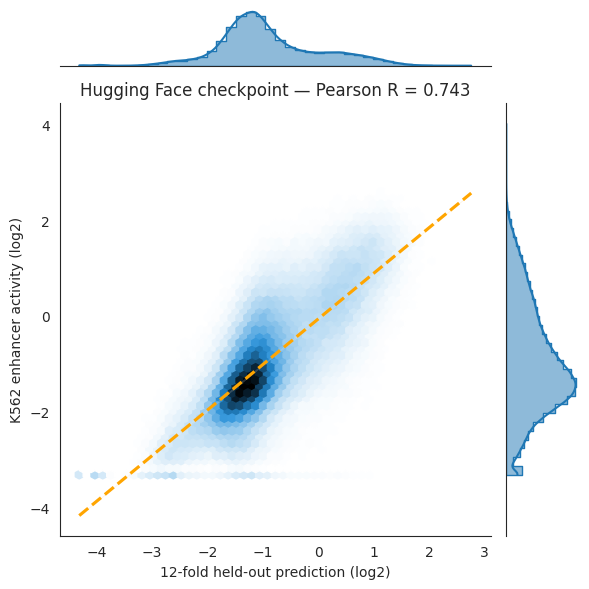

In [6]:
from torch.utils.data import DataLoader
from train_seqEncoder import PeakActivityDataset

assert Path(ENCODER_DATA_CSV).is_file(), ENCODER_DATA_CSV
enc_source_df = pd.read_csv(ENCODER_DATA_CSV)
encoder_split_df = pd.read_csv(SPLIT_CSV, index_col=0)
encoder_split_df['chrom'] = encoder_split_df['chrom'].astype(str).map(
    lambda x: x if x.startswith('chr') else f'chr{x}')

def predict_hf_encoder_fold(fold, batch_size=512):
    test_chrom = encoder_split_df.loc[
        encoder_split_df[f'fold_{fold}'] == 'test', 'chrom'].unique().tolist()
    ds = PeakActivityDataset(CELL, test_chrom, strand='forward', dataframe=enc_source_df)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2,
                        pin_memory=(device == 'cuda'))
    model = enhancer_predictor_256bp()
    checkpoint = torch.load(
        HF_CHECKPOINT_ROOT / 'enhancer_encoders' / CELL / f'fold_{fold}.pt',
        map_location='cpu', weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    model.to(device).eval()

    pred_batches, actual_batches = [], []
    with torch.no_grad():
        for seq, actual, _ in loader:
            seq = seq.float().to(device, non_blocking=True)
            pred_fwd = model(seq)
            pred_rc = model(seq.flip(dims=[-2, -1]))
            pred_batches.append(((pred_fwd + pred_rc) / 2).flatten().cpu())
            actual_batches.append(actual.flatten())
    out = pd.DataFrame({
        'Pred': torch.cat(pred_batches).numpy(),
        'actual': torch.cat(actual_batches).numpy(),
        'fold': fold,
    })
    del model, loader, ds
    if device == 'cuda':
        torch.cuda.empty_cache()
    return out

enc_all = pd.concat([predict_hf_encoder_fold(fold) for fold in range(1, 13)], ignore_index=True)
rE = stats.pearsonr(enc_all['Pred'], enc_all['actual']).statistic
expected_encoder_r = 0.740
print(f'Hugging Face K562 encoder: pooled Pearson R={rE:.4f}, '
      f'expected≈{expected_encoder_r:.3f}, delta={rE-expected_encoder_r:+.4f}, n={len(enc_all):,}')
assert np.isfinite(rE) and abs(rE - expected_encoder_r) <= 0.02

ax = sns.jointplot(data=enc_all, x='Pred', y='actual', kind='hex',
                   marginal_kws={'bins': 40, 'element': 'step', 'kde': True})
ax.plot_joint(sns.regplot, color='r', scatter=False,
              line_kws={'color': 'orange', 'linestyle': 'dashed'})
plt.title(f'Hugging Face checkpoint — Pearson R = {rE:.3f}')
ax.set_axis_labels('12-fold held-out prediction (log2)', 'K562 enhancer activity (log2)')
plt.tight_layout(); plt.show()

## Part 2 — Hugging Face gene-expression checkpoints (`EPInformer_v2`, f3)

Run true held-out inference for K562 RNA and CAGE. Each fold loads the matching checkpoint from
`expression_models/K562/{RNA,CAGE}/f3/`. The f3 architecture uses a frozen enhancer encoder,
three enhancer features, and promoter signal. Constructing the gene dataset preloads its sequence
tensors, so this section needs an HPC node with about 64 GB RAM and preferably one GPU.

In [7]:
from torch.utils.data import Subset, DataLoader
from train_EPInformer import promoter_enhancer_dataset

split_df = pd.read_csv(SPLIT_CSV, index_col=0)
gl = pd.read_csv(f'batch_output/{CELL}/links/GeneList.txt', sep='\t', index_col='name')
gl['promoter_activity'] = np.sqrt(gl['DHS.RPM.TSS1Kb'] * gl['H3K27ac.RPM.TSS1Kb'])
H5_PATH = f'batch_output/{CELL}/encoding/{CELL}_samples.h5'

def hf_expression_checkpoint(cell, assay, fold, feature='f3'):
    matches = sorted((HF_CHECKPOINT_ROOT / 'expression_models' / cell / assay / feature).glob(
        f'fold_{fold}_best_*_checkpoint.pt'))
    if len(matches) != 1:
        raise RuntimeError(f'Expected one checkpoint for {cell}/{assay}/{feature}/fold_{fold}, got {matches}')
    return matches[0]

def predict_subset(model, ds_sub, batch_size=24):
    dl = DataLoader(ds_sub, batch_size=batch_size, shuffle=False, num_workers=2,
                    pin_memory=(device == 'cuda'))
    preds, actual, eids = [], [], []
    model.eval()
    with torch.no_grad():
        for pe, rna, ef, y, _activity, eid in dl:
            pe = pe.float().to(device, non_blocking=True)
            rna = rna.float().to(device, non_blocking=True)
            ef = ef.float().to(device, non_blocking=True)
            out, _ = model(pe, enh_feats=ef, rna_feats=rna)
            preds.extend(out.flatten().cpu().numpy())
            actual.extend(y.numpy())
            eids.extend(eid)
    return pd.DataFrame({'Pred': preds, 'actual': actual}, index=eids)

expected_expression_r = {'RNA': 0.856, 'CAGE': 0.867}
prediction_res, metric_rows = [], []
for assay in ['RNA', 'CAGE']:
    ds = promoter_enhancer_dataset(
        h5_path=H5_PATH, expr_csv=EXPR_CSV, cell_type=CELL, expr_type=assay,
        n_enh_feats=3, distance_thr=100_000, max_n_enh=60,
        use_prm_signal=True, rm_prm_seq=False, promoter_activity_df=gl,
        strand_aware=False)
    ensid_df = pd.DataFrame({'idx': np.arange(len(ds._ensid))}, index=list(ds._ensid))
    for fold in range(1, 13):
        test_ensid = split_df.index[split_df[f'fold_{fold}'] == 'test']
        test_idx = ensid_df.loc[ensid_df.index.intersection(test_ensid), 'idx'].to_numpy()
        model = EPInformer_v2(
            n_encoder=3, n_enhancer=60, out_dim=64, n_extraFeat=3,
            useBN=False, usePromoterSignal=True, useFeat=True, device=device).to(device)
        checkpoint = torch.load(
            hf_expression_checkpoint(CELL, assay, fold), map_location='cpu', weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'], strict=True)
        fold_df = predict_subset(model, Subset(ds, test_idx))
        fold_df['fold'] = fold
        fold_df['expr_type'] = assay
        prediction_res.append(fold_df)
        del model
        if device == 'cuda':
            torch.cuda.empty_cache()

    assay_df = pd.concat([x for x in prediction_res if x['expr_type'].iloc[0] == assay])
    observed = stats.pearsonr(assay_df['Pred'], assay_df['actual']).statistic
    expected = expected_expression_r[assay]
    metric_rows.append({
        'assay': assay, 'observed_pearsonR': observed, 'Hub_card_pearsonR': expected,
        'delta': observed - expected, 'n': len(assay_df),
        'within_0.02': abs(observed - expected) <= 0.02})
    del ds, ensid_df
    gc.collect()

prediction_res = pd.concat(prediction_res)
hf_expression_metrics = pd.DataFrame(metric_rows)
display(hf_expression_metrics)
assert len(prediction_res[prediction_res['expr_type'] == 'RNA']) == 18_377
assert len(prediction_res[prediction_res['expr_type'] == 'CAGE']) == 18_377
assert hf_expression_metrics['within_0.02'].all()

Loading HDF5 data into shared memory...


  Expression column: Actual_K562 (fallback)


Pre-computing pe_ohe and pe_feats for all genes...


Loaded: 18377 genes, pe_ohe: 35.9 GB


Loading HDF5 data into shared memory...


  Expression column: Actual_K562 (fallback)


Pre-computing pe_ohe and pe_feats for all genes...


Loaded: 18377 genes, pe_ohe: 35.9 GB


,assay,observed_pearsonR,Hub_card_pearsonR,delta,n,within_0.02
0,RNA,0.855270,0.856,-0.000730,18377,True
1,CAGE,0.866147,0.867,-0.000853,18377,True


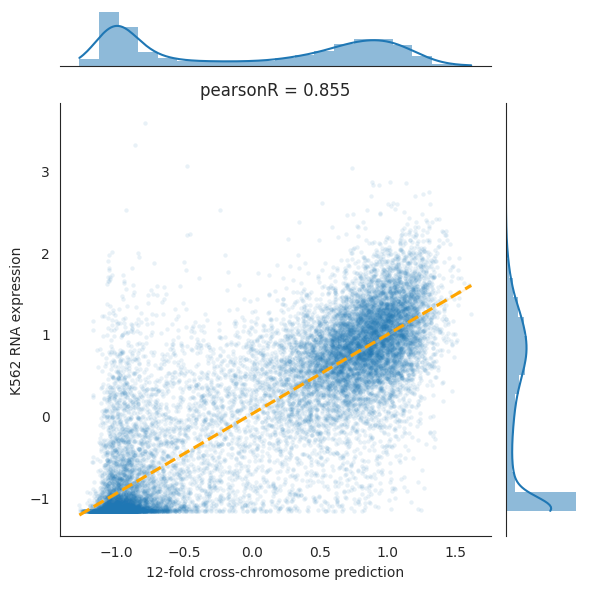

In [8]:
# K562 RNA — predicted vs observed (12-fold pooled)
sub = prediction_res[prediction_res['expr_type'] == 'RNA'].reset_index(drop=True)
rG, _ = stats.pearsonr(sub['Pred'], sub['actual'])
ax = sns.jointplot(data=sub, x='Pred', y='actual', kind='scatter',
                   joint_kws={'marker': 'o', 's': 10, 'alpha': 0.1, 'linewidth': 0},
                   marginal_kws={'bins': 20, 'element': 'step', 'kde': True, 'linewidth': 0})
ax.plot_joint(sns.regplot, color='r', scatter=False, line_kws={'color': 'orange', 'linestyle': 'dashed'})
plt.title(f'pearsonR = {rG:.3f}')
ax.set_axis_labels('12-fold cross-chromosome prediction', 'K562 RNA expression')
plt.tight_layout(); plt.show()

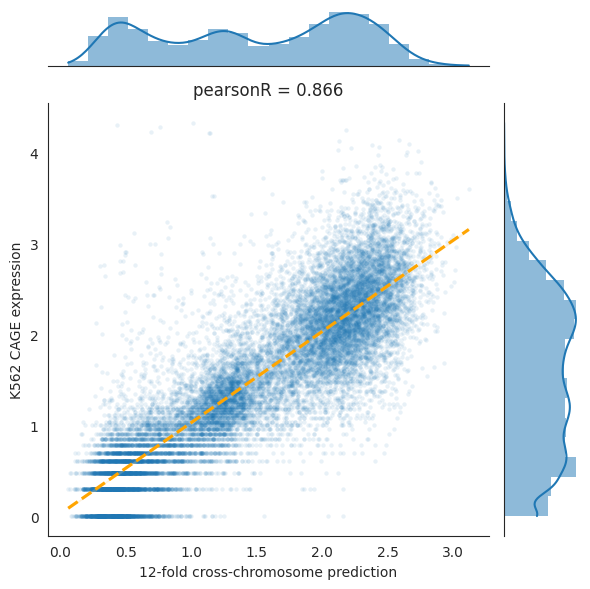

In [9]:
# K562 CAGE — predicted vs observed (12-fold pooled)
sub = prediction_res[prediction_res['expr_type'] == 'CAGE'].reset_index(drop=True)
rG, _ = stats.pearsonr(sub['Pred'], sub['actual'])
ax = sns.jointplot(data=sub, x='Pred', y='actual', kind='scatter',
                   joint_kws={'marker': 'o', 's': 10, 'alpha': 0.1, 'linewidth': 0},
                   marginal_kws={'bins': 20, 'element': 'step', 'kde': True, 'linewidth': 0})
ax.plot_joint(sns.regplot, color='r', scatter=False, line_kws={'color': 'orange', 'linestyle': 'dashed'})
plt.title(f'pearsonR = {rG:.3f}')
ax.set_axis_labels('12-fold cross-chromosome prediction', 'K562 CAGE expression')
plt.tight_layout(); plt.show()

### Cross-check against the full pipeline validation

The table below reads the independently generated 12-fold evaluation summaries from the full
pipeline run. It is a second check, separate from the fresh Hugging Face inference above.

In [10]:
PIPELINE_EXPR_DIR = {
    'K562': 'K562_overnight_RNA', 'GM12878': 'GM12878_overnight_RNA',
    'HepG2': 'HepG2_overnight_RNA', 'HUVEC': 'HUVEC_overnight_RNA',
    'NHEK': 'NHEK_overnight_RNA', 'H1': 'H1_overnight_RNA'}
HUB_RNA_REFERENCE = {
    'K562': 0.856, 'GM12878': 0.860, 'HepG2': 0.845,
    'HUVEC': 0.839, 'NHEK': 0.828, 'H1': 0.781}

rows = []
for cell, dirname in PIPELINE_EXPR_DIR.items():
    summary_path = Path('EPInformer_models') / dirname / 'evaluation' / 'expression_eval_summary.csv'
    if not summary_path.is_file():
        continue
    all_row = pd.read_csv(summary_path).query("fold == 'ALL'").iloc[0]
    rows.append({
        'cell': cell,
        'pipeline_pearsonR': all_row['pearsonr'],
        'Hub_card_pearsonR': HUB_RNA_REFERENCE[cell],
        'delta': all_row['pearsonr'] - HUB_RNA_REFERENCE[cell],
        'n': int(all_row['n']),
    })
pipeline_comparison = pd.DataFrame(rows).sort_values('cell').reset_index(drop=True)
display(pipeline_comparison)
if len(pipeline_comparison):
    assert (pipeline_comparison['n'] == 18_377).all()
    assert (pipeline_comparison['delta'].abs() <= 0.02).all()

,cell,pipeline_pearsonR,Hub_card_pearsonR,delta,n
0,GM12878,0.858105,0.860,-0.001895,18377
1,H1,0.776906,0.781,-0.004094,18377
2,HUVEC,0.837467,0.839,-0.001533,18377
3,HepG2,0.844562,0.845,-0.000438,18377
4,K562,0.860231,0.856,0.004231,18377
5,NHEK,0.828580,0.828,0.000580,18377
